<center><h1>Kim_Seonmin_HW2</h1></center>
<br>

Name: Seonmin Kim
<br>
Github Username: nimnusmik

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

pd.set_option('display.float_format', '{:.4f}'.format)

Get the Cycle Power Plant Data Set

In [2]:
df = pd.read_excel('../data/CCPP/Folds5x2_pp.xlsx', sheet_name='Sheet1')
df.head()

,AT,V,AP,RH,PE
0,14.9600,41.7600,1024.0700,73.1700,463.2600
1,25.1800,62.9600,1020.0400,59.0800,444.3700
2,5.1100,39.4000,1012.1600,92.1400,488.5600
3,20.8600,57.3200,1010.2400,76.6400,446.4800
4,10.8200,37.5000,1009.2300,96.6200,473.9000


### (b) Exploring the data

#### i. rows and columns

In [3]:
print('rows:', df.shape[0], ' columns:', df.shape[1])
df.info()

rows: 9568  columns: 5
<class 'pandas.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


There are **9568 rows** and **5 columns**.
- Each row is one hourly average measurement of the power plant running at full load (2006–2011).
- The columns are the 4 input variables — AT (temperature), V (exhaust vacuum), AP (ambient pressure), RH (relative humidity) — and the output PE (net hourly electrical energy output), which we want to predict.

#### ii. pairwise scatterplots of all the varianbles

A grid of scatterplots showing every pair of variables against each other

        AT       V      AP      RH      PE
AT  1.0000  0.8441 -0.5075 -0.5425 -0.9481
V   0.8441  1.0000 -0.4135 -0.3122 -0.8698
AP -0.5075 -0.4135  1.0000  0.0996  0.5184
RH -0.5425 -0.3122  0.0996  1.0000  0.3898
PE -0.9481 -0.8698  0.5184  0.3898  1.0000


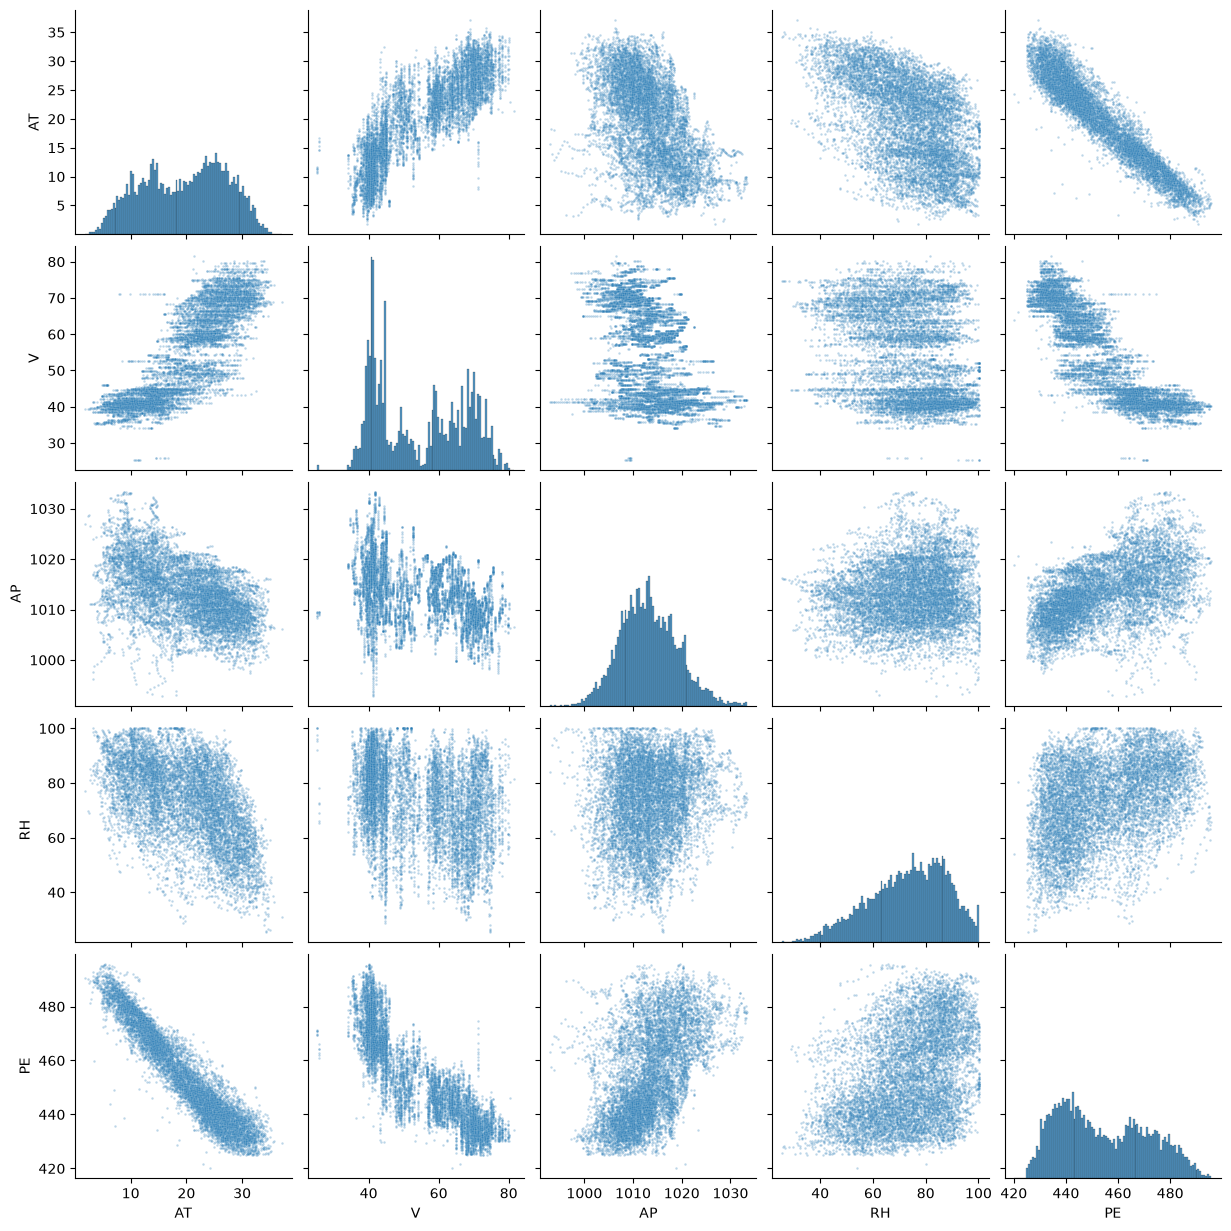

In [4]:
print(df.corr())

sns.pairplot(df, plot_kws={'s': 3, 'alpha': 0.3}, diag_kws={'bins': 100})
plt.show()


**Findings**
1. `AT` vs `PE` has a strong negative relationship (r ≈ −0.95). So I believe hotter air means less power.
2. Also `V` vs `PE` is in negative relationship (r ≈ −0.87), which means the more V, the lesser PE
3. `AT` and `V` are strongly correlated (r ≈ 0.84). I expect collinearity in the multiple regression.
4. Other than above, I couldn't find some strong relationships

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [5]:
Data = pd.DataFrame({
    'mean': df.mean(),
    'median': df.median(),
    'min': df.min(),
    'max': df.max(),
    'range': df.max() - df.min(),
    'Q1': df.quantile(0.25),
    'Q3': df.quantile(0.75),
    'IQR': df.quantile(0.75) - df.quantile(0.25),
})
Data

,mean,median,min,max,range,Q1,Q3,IQR
AT,19.6512,20.3450,1.8100,37.1100,35.3000,13.5100,25.7200,12.2100
V,54.3058,52.0800,25.3600,81.5600,56.2000,41.7400,66.5400,24.8000
AP,1013.2591,1012.9400,992.8900,1033.3000,40.4100,1009.1000,1017.2600,8.1600
RH,73.3090,74.9750,25.5600,100.1600,74.6000,63.3275,84.8300,21.5025
PE,454.3650,451.5500,420.2600,495.7600,75.5000,439.7500,468.4300,28.6800


### (c) Simple Linear Regression

In [6]:
simple = {}
rows = []
PREDICTORS = ['AT', 'V', 'AP', 'RH']

for i in PREDICTORS: 
    m = smf.ols(f'PE ~ {i}', data=df).fit()
    
    simple[i] = m
    rows.append({'predictor': i, 
                 'intercept': m.params['Intercept'], 
                 'slope': m.params[i],
                 't': m.tvalues[i], 
                 'p-value': m.pvalues[i],
                 'R2': m.rsquared,
                })

result = pd.DataFrame(rows).set_index('predictor')
result

,intercept,slope,t,p-value,R2
predictor,,,,,
AT,497.0341,-2.1713,-291.7152,0.0000,0.8989
V,517.8015,-1.1681,-172.4015,0.0000,0.7565
AP,-1055.2610,1.4899,59.2962,0.0000,0.2688
RH,420.9618,0.4557,41.3987,0.0000,0.1519


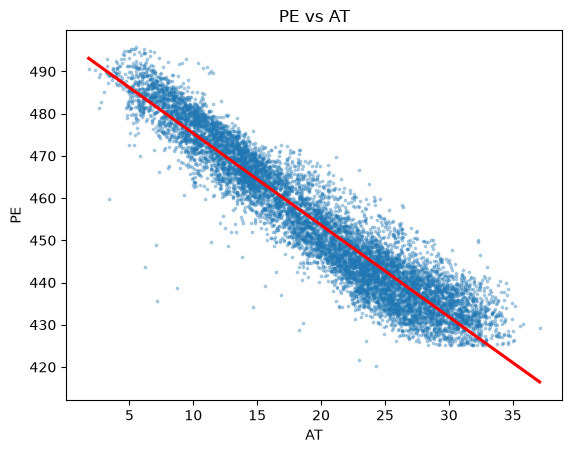

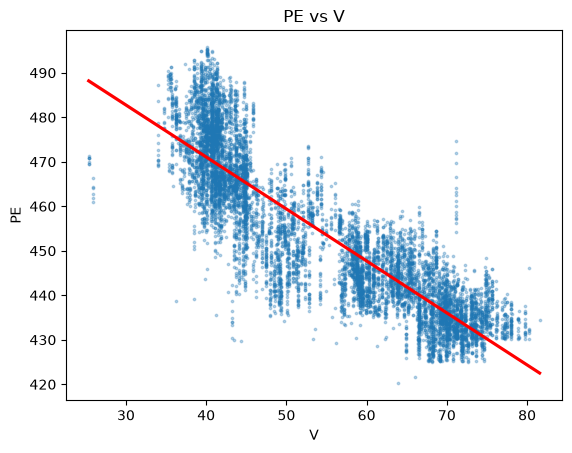

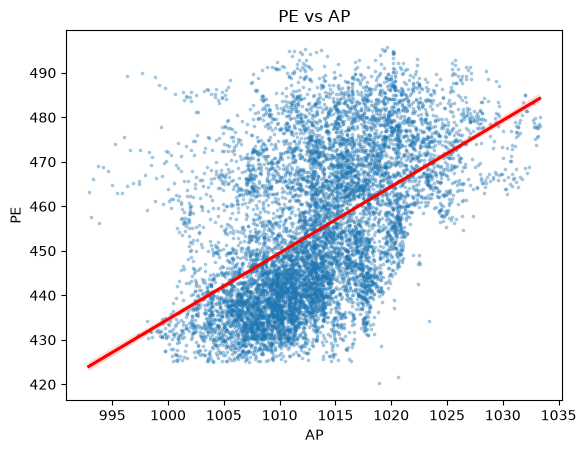

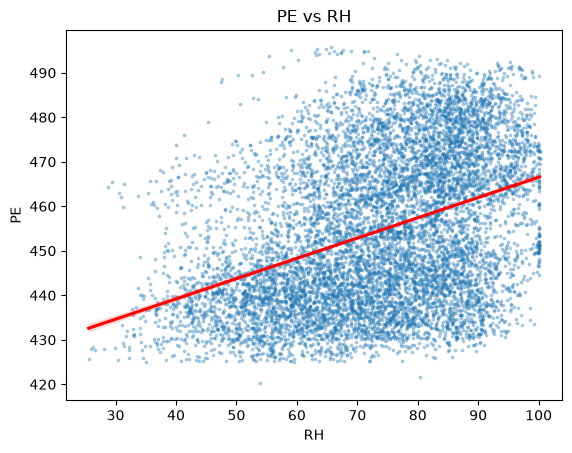

In [7]:
for p in PREDICTORS:
    sns.regplot(x=p, y='PE', data=df, scatter_kws={'s': 3, 'alpha': 0.3}, line_kws={'color': 'red'})
    plt.title(f'PE vs {p}')
    plt.show()

In [8]:
for p in PREDICTORS:
    stud = simple[p].get_influence().resid_studentized_external
    print(p, 'outliers:', (abs(stud) > 3).sum())

AT outliers: 42


V outliers: 33


AP outliers: 30


RH outliers: 2


##### findings
All four slopes have p-values of essentially 0 (< 0.05), so every predictor has a statistically significant association with PE.
AT (R² ≈ 0.90) and V (R² ≈ 0.76) explain most of the variation, while AP (R² ≈ 0.27) and RH (R² ≈ 0.15) explain much less.

There are a few points with studentized residuals beyond ±3, but they make up less than 0.5% of the data and are real measurements, so I did not remove them.

### (d) Multiple Regression

In [9]:
multiple = smf.ols('PE ~ AT + V + AP + RH', data=df).fit()
print(multiple.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:51:20   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.0

#### finding
- I firstly checked  P-value and all four predictors have p <0.001 which means we can reject H₀: βⱼ = 0 for AT, V, AP and RH.
- I found R² ≈ 0.929, which is better than the best single-predictor model.
- Among the four predictors, AT and V are the most strongly correlated pair, so they are the main source of the collinearity.

### (e) 1c Compare to 1d

In [10]:
coef = pd.DataFrame({'simple': [simple[p].params[p] for p in PREDICTORS],
                     'multiple': multiple.params[PREDICTORS].values}, index=PREDICTORS
                    )
print(coef)

    simple  multiple
AT -2.1713   -1.9775
V  -1.1681   -0.2339
AP  1.4899    0.0621
RH  0.4557   -0.1581


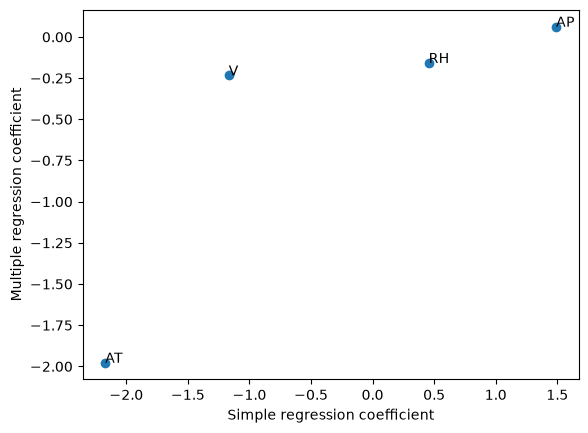

In [11]:
simple_coef = [simple[p].params[p] for p in PREDICTORS]    
multi_coef  = [multiple.params[p] for p in PREDICTORS]        

plt.scatter(simple_coef, multi_coef)

for p, x, y in zip(PREDICTORS, simple_coef, multi_coef):
  plt.text(x, y, p)     

plt.xlabel('Simple regression coefficient')
plt.ylabel('Multiple regression coefficient')
plt.show()

##### By variables
- AT(−2.17 → −1.98): It almost unchanged. AT is the main driver of PE.      
- V (−1.17 → −0.23): It shrinks a lot. On its own, V was picking up the effect of temperature.
- AP(+1.49 → +0.06): It drops to almost zero. It was also borrowing the effect of temperature.
- RH(+0.46 → −0.16): The sign flips.

##### Conclusion
Simple regressions can be misleading because they mix in the effects of other, correlated variables. When predictors are correlated, the multiple regression gives a more reliable picture of each variable's own effect.

### (f) Nonlinear Association

In [12]:
rows = []

for p in PREDICTORS:
    d = pd.DataFrame({'PE': df['PE'], 'x': df[p] - df[p].mean()})
    m = smf.ols('PE ~ x + I(x**2) + I(x**3)', data=d).fit()
    
    rows.append({'predictor': p, 
                 'p(X)': m.pvalues['x'], 
                 'p(X²)': m.pvalues['I(x ** 2)'],
                 'p(X³)': m.pvalues['I(x ** 3)'], 
                 'R2 linear': simple[p].rsquared, 'R2 cubic': m.rsquared})
    

In [13]:
poly_table = pd.DataFrame(rows).set_index('predictor')

poly_table['R2 gain'] = poly_table['R2 cubic'] - poly_table['R2 linear']
poly_table

,p(X),p(X²),p(X³),R2 linear,R2 cubic,R2 gain
predictor,,,,,,
AT,0.0000,0.0000,0.0000,0.8989,0.9119,0.0129
V,0.0000,0.0000,0.0137,0.7565,0.7750,0.0185
AP,0.0000,0.0000,0.0000,0.2688,0.2975,0.0288
RH,0.0000,0.1014,0.0000,0.1519,0.1537,0.0018


##### findings
  
There is evidence of a non-linear association for all four predictors However, the gain in R² over the linear model is small (at most about 0.03). For RH it is only about 0.002, so its non-linearity is statistically significant but practically negligible.

- For AT and AP, both the X² and X³ terms are significant.
- For V, both terms are significant, although the X³ term is only moderately so (p ≈ 0.014).
- For RH, the X² term is not significant (p ≈ 0.10), but the X³ term is, so there is still evidence of non-linearity.

### (g) Interactions of Predictors

In [14]:
inter = smf.ols('PE ~ (AT + V + AP + RH)**2', data=df).fit()
print(inter.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:51:20   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

In [15]:
pvals = inter.pvalues                    
pvals = pvals[pvals.index.str.contains(':')]

table = pd.DataFrame({'p-value': pvals})
table['significant'] = table['p-value'] < 0.05
table

,p-value,significant
AT:V,0.0000,True
AT:AP,0.4521,False
AT:RH,0.0000,True
V:AP,0.0000,True
V:RH,0.0862,False
AP:RH,0.0336,True


##### findings
 At α = 0.05, four of the six interaction terms are statistically significant, while AT:AP and V:RH are not. 
 So there is evidence that the effect of one predictor depends on the level of another. R² increases slightly from 0.929 to 0.936.

### (h) Improvement

In [16]:
train, test = train_test_split(df, test_size=0.3, random_state=42)
m_lin = smf.ols('PE ~ AT + V + AP + RH', data=train).fit()

m1 = smf.ols('PE ~ AT + V + AP + RH + I(AT**2) + I(V**2) + I(AP**2) + I(RH**2)'
             ' + AT:V + AT:AP + AT:RH + V:AP + V:RH + AP:RH', data=train).fit()
print(m1.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7272.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:51:20   Log-Likelihood:                -19160.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6682   BIC:                         3.845e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -7664.9809   1429.568     -5.362      0.0

In [17]:
m2 = smf.ols('PE ~ AT + V + AP + RH + I(AT**2) + I(V**2) + I(AP**2) + I(RH**2)'
             ' + AT:V + AT:AP + AT:RH + V:AP + AP:RH', data=train).fit()
print(m2.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7832.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:51:20   Log-Likelihood:                -19160.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6683   BIC:                         3.844e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -7677.4947   1427.498     -5.378      0.0

In [18]:
m3 = smf.ols('PE ~ AT + V + AP + RH + I(AT**2) + I(AP**2) + I(RH**2)'
             ' + AT:V + AT:AP + AT:RH + V:AP + AP:RH', data=train).fit()
print(m3.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     8486.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:51:20   Log-Likelihood:                -19160.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6684   BIC:                         3.844e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -7693.6035   1427.075     -5.391      0.0

In [19]:
m_poly = smf.ols('PE ~ AT + V + AP + RH + I(AT**2) + I(AP**2) + I(RH**2)'
                 ' + AT:V + AT:AP + AT:RH + AP:RH', data=train).fit()
print(m_poly.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     9258.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:51:20   Log-Likelihood:                -19161.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6685   BIC:                         3.843e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -7568.5210   1420.561     -5.328      0.0

In [20]:
for name, m in [('Linear', m_lin), ('Reduced poly', m_poly)]:
    train_mse = mean_squared_error(train['PE'], m.predict(train))
    test_mse  = mean_squared_error(test['PE'],  m.predict(test))
    print(name, 'train:', round(train_mse, 2), 'test:', round(test_mse, 2))

Linear train: 20.58 test: 21.24
Reduced poly train: 17.89 test: 18.66


##### findings
Starting from all 14 terms, I removed the term with the largest p-value one at a time until every remaining term had p < 0.05:
1. V:RH (p ≈ 0.87)
2. V² (p ≈ 0.61)
3. V:AP (p ≈ 0.36)

The main effects AT, V, AP, RH were kept because they still appear in interaction terms (hierarchy principle).
The reduced model has lower train MSE (20.58 → 17.89) and lower test MSE (21.24 → 18.66) than the linear model, so the interaction and quadratic terms do improve the model.

### (i) KNN

In [21]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

X_train, X_test = train[PREDICTORS], test[PREDICTORS]
y_train, y_test = train['PE'], test['PE']

scaler = StandardScaler().fit(X_train)
X_train_n, X_test_n = scaler.transform(X_train), scaler.transform(X_test)

In [22]:

def run_knn(Xtr, Xte):
    train_err, test_err = [], []
    for k in range(1, 101):
        knn = KNeighborsRegressor(n_neighbors=k).fit(Xtr, y_train)
        train_err.append(mean_squared_error(y_train, knn.predict(Xtr)))
        test_err.append(mean_squared_error(y_test, knn.predict(Xte)))
    return train_err, test_err

raw_tr, raw_te = run_knn(X_train, X_test)
norm_tr, norm_te = run_knn(X_train_n, X_test_n)

print('raw  best k:', np.argmin(raw_te) + 1, ' test MSE:', min(raw_te))
print('norm best k:', np.argmin(norm_te) + 1, ' test MSE:', min(norm_te))

raw  best k: 5  test MSE: 15.726819842563568
norm best k: 4  test MSE: 14.305669422675024


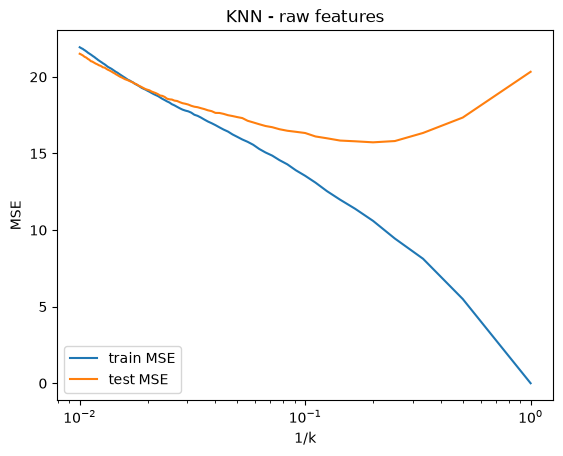

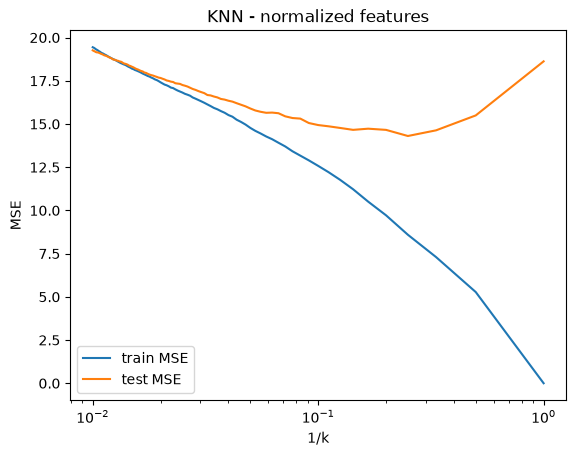

In [23]:
ks = np.arange(1, 101)
for name, tr, te in [('raw', raw_tr, raw_te), ('normalized', norm_tr, norm_te)]:
    plt.plot(1/ks, tr, label='train MSE')
    plt.plot(1/ks, te, label='test MSE')
    plt.xscale('log')
    plt.xlabel('1/k'); plt.ylabel('MSE'); plt.title(f'KNN - {name} features')
    plt.legend(); plt.show()

####  Finding
The best k is 5 for raw features (test MSE ≈ 15.7) and 4 for normalized features (test MSE ≈ 14.3). Normalizing helps because otherwise the variables with the largest ranges dominate the distance. **As 1/k increases, the train error drops toward zero while the test error follows a U shape.**

### (j ) Compare KNN and Linear

In [24]:
compare = pd.DataFrame({
    'test MSE': [
        mean_squared_error(test['PE'], m_lin.predict(test)),
        mean_squared_error(test['PE'], m_poly.predict(test)),
        min(raw_te),
        min(norm_te),
    ]
}, index=['Linear', 'Reduced poly', 'KNN raw', 'KNN normalized'])

compare.sort_values('test MSE')

,test MSE
KNN normalized,14.3057
KNN raw,15.7268
Reduced poly,18.6600
Linear,21.2399


##### findings
- The best linear regression model is the reduced model from (h), with test MSE ≈ 18.66.
- KNN does better: normalized KNN reaches test MSE ≈ 14.31, and even raw KNN (≈ 15.73) beats the regression model.
- I think this is because the relationship has curves and interactions (see f and g). Regression can only use the formula I give it, but KNN just looks at similar past hours, so it can follow a complicated shape. With only 4 predictors and about 6,700 training rows, there are enough close neighbors for this to work.
- On the other hand, KNN has no coefficients or p-values, so it cannot explain how each variable affects PE. For prediction I would pick normalized KNN, and for understanding the variables I would use regression.

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

**Better.** With lots of data, a flexible method can fit the true shape of f closely without its variance blowing up.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

**Worse.** With few observations and many predictors, a flexible method will overfit the noise (high variance). A simpler, inflexible method generalizes better.

### (c) The relationship between the predictors and response is highly non-linear.

**Better.** An inflexible (e.g. linear) method has large bias here. A flexible method can follow the curvature.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

**Worse.** A flexible method would chase the noise and have high variance. An inflexible method is more robust to noisy data.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

In [25]:
data = pd.DataFrame({'X1': [0, 2, 0, 0, -1, 1], 
                    'X2': [3, 0, 1, 1, 0, 1], 
                    'X3': [0, 0, 3, 2, 1, 1],
                    'Y': ['Red', 'Red', 'Red', 'Green', 'Green', 'Red']},
                   index=range(1, 7))

data['distance'] = np.sqrt((data[['X1', 'X2', 'X3']] ** 2).sum(axis=1))
data

,X1,X2,X3,Y,distance
1,0,3,0,Red,3.0000
2,2,0,0,Red,2.0000
3,0,1,3,Red,3.1623
4,0,1,2,Green,2.2361
5,-1,0,1,Green,1.4142
6,1,1,1,Red,1.7321


### (b) What is our prediction with K = 1? Why?

In [26]:
data.nsmallest(1, 'distance')

,X1,X2,X3,Y,distance
5,-1,0,1,Green,1.4142


**Green.** The single nearest neighbor is obs 5

### (c) What is our prediction with K = 3? Why?

In [27]:
nearest3 = data.nsmallest(3, 'distance')
display(nearest3)
nearest3['Y'].value_counts()

,X1,X2,X3,Y,distance
5,-1,0,1,Green,1.4142
6,1,1,1,Red,1.7321
2,2,0,0,Red,2.0000


Y
Red      2
Green    1
Name: count, dtype: int64

**Red.** The three nearest neighbors are obs 5 (Green), obs 6 (Red) and obs 2 (Red). Red wins the vote 2–1, so P(Red) = 2/3.

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

**Small.** A small K gives a flexible, wiggly decision boundary that can follow a highly non-linear shape. A large K averages over many points and produces a smoother, nearly linear boundary, which would have high bias here.

## References
1. UCI Machine Learning Repository — Combined Cycle Power Plant Data Set: https://archive.ics.uci.edu/ml/datasets/Combined+Cycle+Power+Plant
2. G. James, D. Witten, T. Hastie, R. Tibshirani, *An Introduction to Statistical Learning*, Ch. 2–3.
3. statsmodels — OLS formula API: https://www.statsmodels.org/stable/example_formulas.html
4. scikit-learn — Polynomial features: https://scikit-learn.org/stable/modules/preprocessing.html#generating-polynomial-features
5. scikit-learn — KNeighborsRegressor, StandardScaler: https://scikit-learn.org/stable/modules/neighbors.html#regression

## AI Usage Disclosure
I used Claude (Anthropic) as a learning aid for this assignment, as allowed by the syllabus.

**How it was used**
- Claude first generated a reference solution. I then worked through it part by part, asked Claude to explain the concepts and code (pairwise scatterplots, hypothesis testing / p-values, collinearity, interaction terms, backward elimination, KNN and normalization), and rewrote the code in this notebook myself, using simpler versions where the original was too complex for me.
- Parts of the written answers were drafted or translated into English by Claude and then edited by me: the findings in (b)i, (c), (d)–(j), and the ISLR 2.4.1 / 2.4.7 answers.
- Claude added the train/test error plot in (i), the findings text in (b)i, (c), (h), (j), fixed a bug where `m_lin` was not defined when running all cells, and fixed typos.

**Main prompts used** (originally in Korean, translated)
- "Help me complete this homework using this PDF and data, and submit a public GitHub repo."
- "What is a pairwise scatterplot? Explain in one line of English and one line of Korean."
- "Explain this code line by line, it is too hard" (for the simple regression loop, the backward elimination code, and the comparison table).
- "What does it mean to reject H₀?" / "What can we learn from this plot?"
- "What is KNN asking me to do?"
- "Write this finding in English."
- "Fix the bug and add the missing parts (the (i) plot and the missing findings)."

**Citation (MLA)**
"Help me complete this homework using this PDF and data" prompt. *Claude*, Opus 5.5 version, Anthropic, 25 Sept. 2026.